# Machine Learning Project

**The Hashemite University - Machine Learning (2010042321)**  
**First Semester 2024/2025**

### Team Members
- Amjad Mohammad Alqawas - 2234781
- Ahmada Shaher Alhabaibeh - 2234350
- Faten Ayman Alshouyat - 2238258
- Ahmad Rami Alsafadi - 2235807
- Mohamad Jamal Ishaq - 2232421

This notebook implements the project requirements in three parts:

1. CO2 emissions data analysis and visualization.
2. Multiple linear regression with forward feature selection.
3. Loan approval classification using five algorithms, hold-out validation, and 10-fold cross-validation.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import f_oneway

from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

CO2_FILE = Path('CO2 Emissions4.csv')
LOAN_FILE = Path('loan_approval_dataset4.csv')

for file_path in [CO2_FILE, LOAN_FILE]:
    if not file_path.exists():
        raise FileNotFoundError(
            f"{file_path} was not found. Place the CSV files in the same folder as this notebook."
        )

print('Setup completed successfully.')

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-o2vurtdm because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup completed successfully.


---
# Part 1: Data Analysis and Visualization

## 1.1 Load and inspect the CO2 emissions dataset

The raw dataset is inspected first. Exact duplicate rows are reported and then removed before modeling so that identical records cannot appear in both training and testing sets.

In [2]:
co2_raw = pd.read_csv(CO2_FILE)
co2_raw.columns = [column.strip().replace("'", "") for column in co2_raw.columns]

print('First five rows:')
display(co2_raw.head())

co2_overview = pd.DataFrame({
    'Column': co2_raw.columns,
    'Non-Null Count': co2_raw.notna().sum().values,
    'Missing Values': co2_raw.isna().sum().values,
    'Data Type': co2_raw.dtypes.astype(str).values,
})
print('\nDataset information:')
display(co2_overview)

print(f"Raw dimensions: {co2_raw.shape[0]:,} rows x {co2_raw.shape[1]} columns")
print(f"Exact duplicate rows: {co2_raw.duplicated().sum():,}")

co2_data = co2_raw.drop_duplicates().reset_index(drop=True)
print(f"Dimensions after removing exact duplicates: {co2_data.shape[0]:,} rows x {co2_data.shape[1]} columns")

First five rows:


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,PORSCHE,'911 GT3RS',TWO-SEATER,4.0000,6,AM7,Z,16.3000,11.8000,14.3000,20,334
1,BMW,M3,COMPACT,3.0000,6,M6,Z,13.7000,9.0000,11.6000,24,271
2,VOLKSWAGEN,'GOLF SPORTWAGON TDI (modified)','STATION WAGON - SMALL',2.0000,4,M6,D,7.6000,5.5000,6.7000,42,179
3,BMW,'335i xDRIVE SEDAN',COMPACT,3.0000,6,AS8,Z,11.9000,7.8000,10.0000,28,230
4,MASERATI,'QUATTROPORTE GTS',FULL-SIZE,3.8000,8,AS8,Z,17.6000,10.7000,14.5000,19,334



Dataset information:


,Column,Non-Null Count,Missing Values,Data Type
0,Make,7385,0,object
1,Model,7385,0,object
2,Vehicle Class,7385,0,object
3,Engine Size(L),7385,0,float64
4,Cylinders,7385,0,int64
5,Transmission,7385,0,object
6,Fuel Type,7385,0,object
7,Fuel Consumption City (L/100 km),7385,0,float64
8,Fuel Consumption Hwy (L/100 km),7385,0,float64
9,Fuel Consumption Comb (L/100 km),7385,0,float64


Raw dimensions: 7,385 rows x 12 columns
Exact duplicate rows: 5,692
Dimensions after removing exact duplicates: 1,693 rows x 12 columns


## 1.2 CO2 Data Preprocessing and Data-Quality Decisions

Before visualization and modeling, the following preprocessing steps are applied:

- Column names are standardized by removing surrounding spaces and apostrophes.
- Data types and missing-value counts are checked; the dataset contains no missing values.
- Exact duplicate rows are removed before the train/test split so identical records cannot appear in both subsets.
- Valid high or low measurements are retained because the project instructions do not require outlier removal.
- Feature scaling is not required for ordinary Multiple Linear Regression because the model can be fitted in the original measurement units.

The cleaned dataset is then used consistently throughout Parts 1 and 2.

## 1.3 Descriptive Statistics

In [3]:
numerical_columns = co2_data.select_dtypes(include=np.number).columns.tolist()
print('Descriptive statistics for numerical features:')
display(co2_data[numerical_columns].describe().T)

Descriptive statistics for numerical features:


,count,mean,std,min,25%,50%,75%,max
Engine Size(L),"1,693.0000",3.1671,1.3575,1.0000,2.0000,3.0000,3.7000,6.8000
Cylinders,"1,693.0000",5.6108,1.8278,3.0000,4.0000,6.0000,6.0000,12.0000
Fuel Consumption City (L/100 km),"1,693.0000",12.5662,3.5081,4.2000,10.0000,12.0000,14.6000,30.3000
Fuel Consumption Hwy (L/100 km),"1,693.0000",9.0395,2.2418,4.2000,7.4000,8.7000,10.2000,20.5000
Fuel Consumption Comb (L/100 km),"1,693.0000",10.9790,2.9056,4.2000,8.9000,10.5000,12.6000,25.9000
Fuel Consumption Comb (mpg),"1,693.0000",27.4347,7.1082,11.0000,22.0000,27.0000,32.0000,67.0000
CO2 Emissions(g/km),"1,693.0000",250.3828,58.3989,99.0000,207.0000,244.0000,288.0000,493.0000


## 1.4 Visualization Task: Six Scatterplots

Six clearly separated scatterplots are used to study the relationships among engine size, the different fuel-consumption measurements, and CO2 emissions. A fitted regression line is added to each plot to make the overall direction easier to interpret.

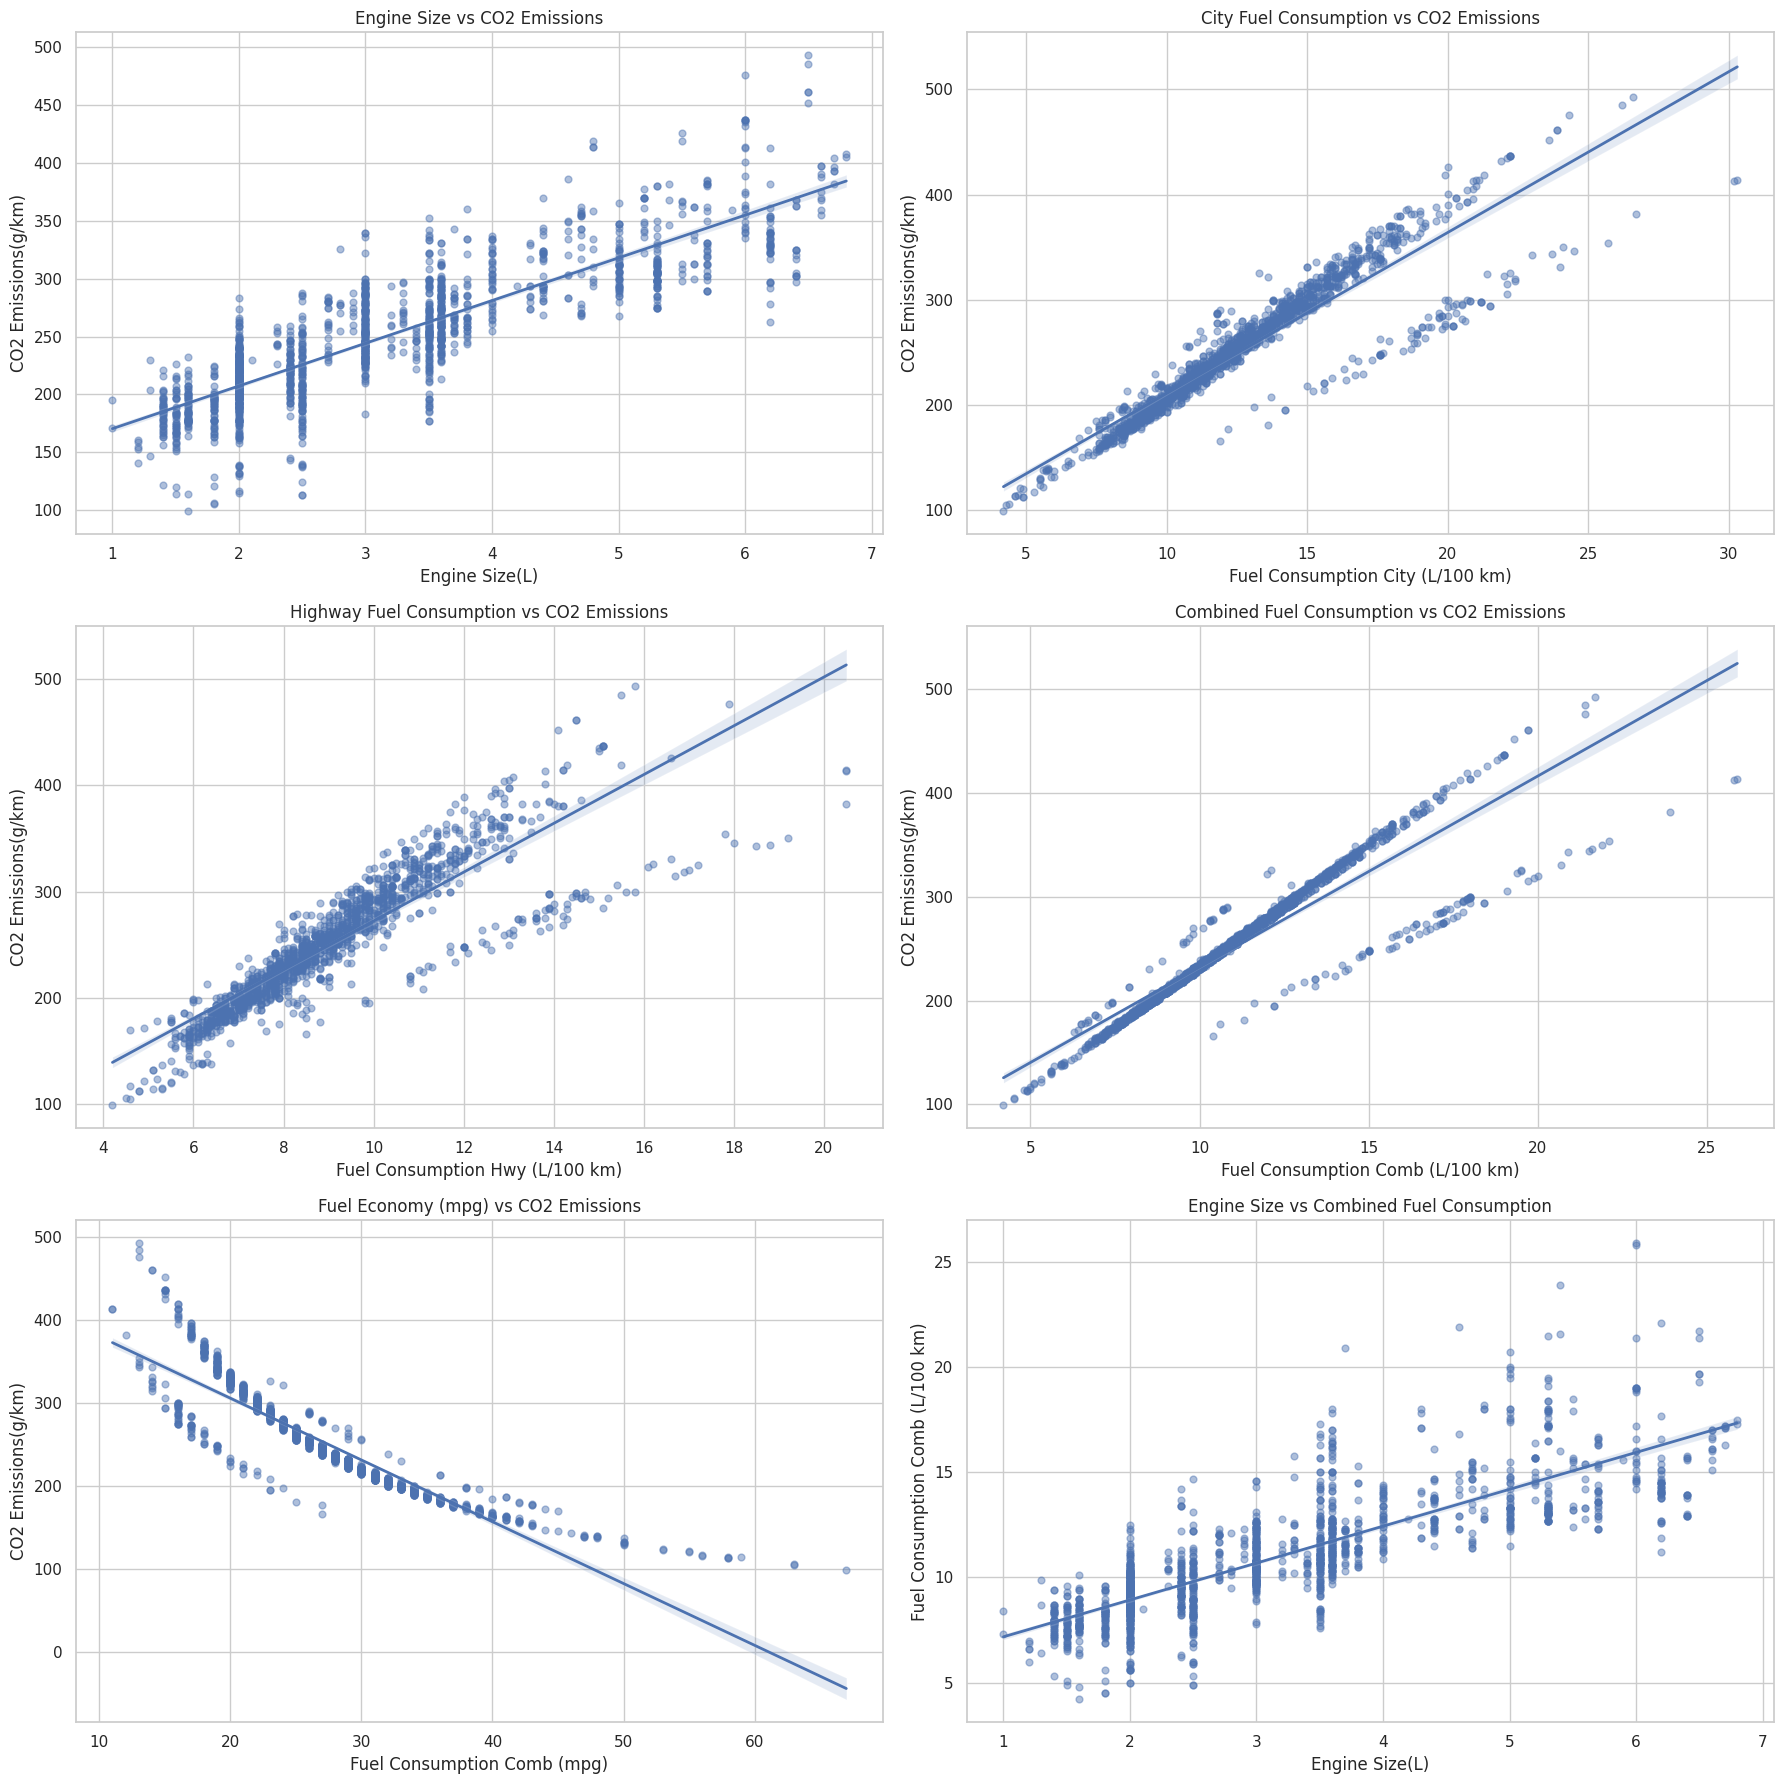

In [4]:
scatter_relationships = [
    ('Engine Size(L)', 'CO2 Emissions(g/km)', 'Engine Size vs CO2 Emissions'),
    ('Fuel Consumption City (L/100 km)', 'CO2 Emissions(g/km)', 'City Fuel Consumption vs CO2 Emissions'),
    ('Fuel Consumption Hwy (L/100 km)', 'CO2 Emissions(g/km)', 'Highway Fuel Consumption vs CO2 Emissions'),
    ('Fuel Consumption Comb (L/100 km)', 'CO2 Emissions(g/km)', 'Combined Fuel Consumption vs CO2 Emissions'),
    ('Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)', 'Fuel Economy (mpg) vs CO2 Emissions'),
    ('Engine Size(L)', 'Fuel Consumption Comb (L/100 km)', 'Engine Size vs Combined Fuel Consumption'),
]

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for axis, (x_column, y_column, title) in zip(axes, scatter_relationships):
    sns.regplot(
        data=co2_data,
        x=x_column,
        y=y_column,
        scatter_kws={'alpha': 0.45, 's': 24},
        line_kws={'linewidth': 2},
        ax=axis,
    )
    axis.set_title(title)
    axis.set_xlabel(x_column)
    axis.set_ylabel(y_column)

plt.tight_layout()
plt.show()

## 1.5 Visualization Task: Pair Plot

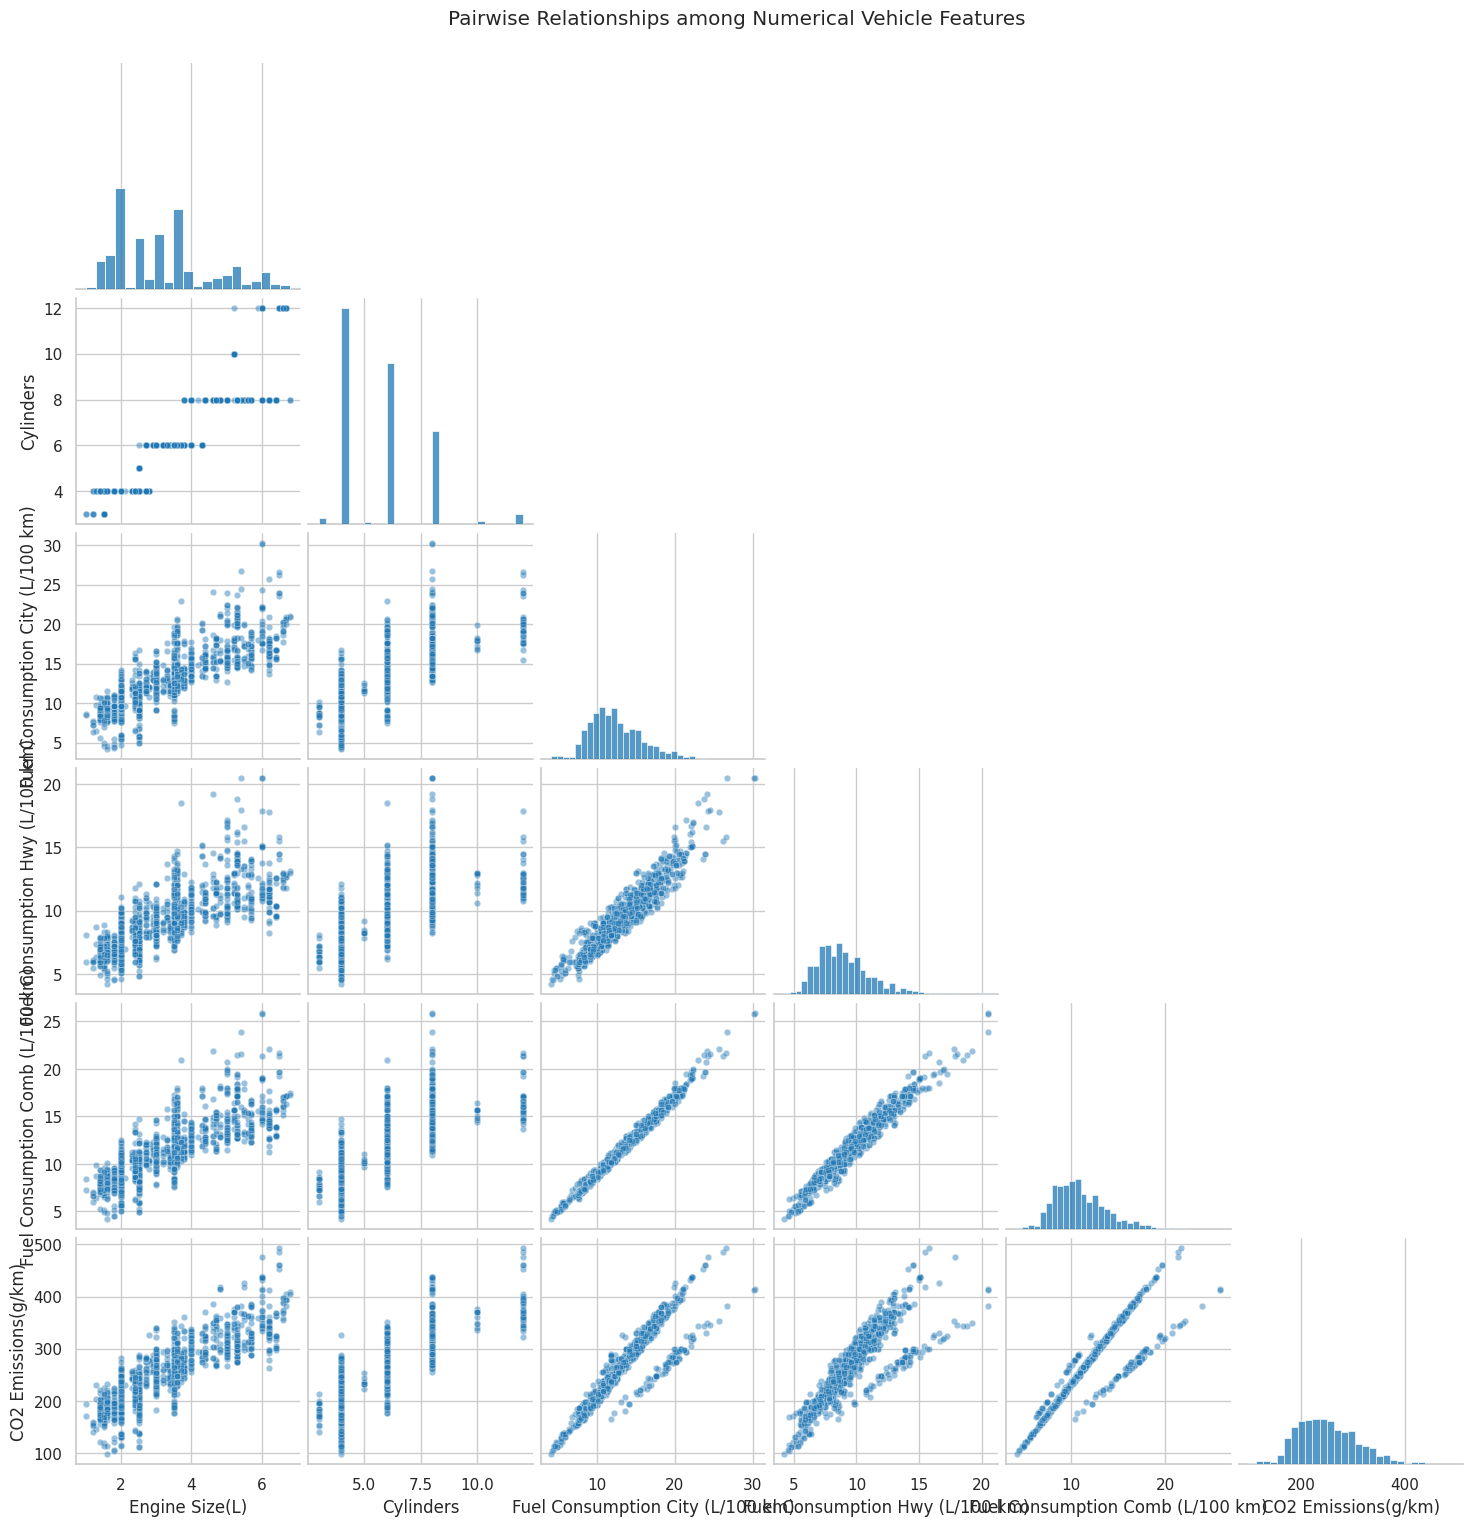

In [5]:
pair_columns = [
    'Engine Size(L)',
    'Cylinders',
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (L/100 km)',
    'CO2 Emissions(g/km)',
]

pair_plot = sns.pairplot(
    co2_data[pair_columns],
    diag_kind='hist',
    corner=True,
    plot_kws={'alpha': 0.45, 's': 22, 'color': 'tab:blue'},
    diag_kws={'color': 'tab:blue'},
)
pair_plot.fig.suptitle('Pairwise Relationships among Numerical Vehicle Features', y=1.02)
plt.show()

## 1.6 Visualization Task: Categorical Variables

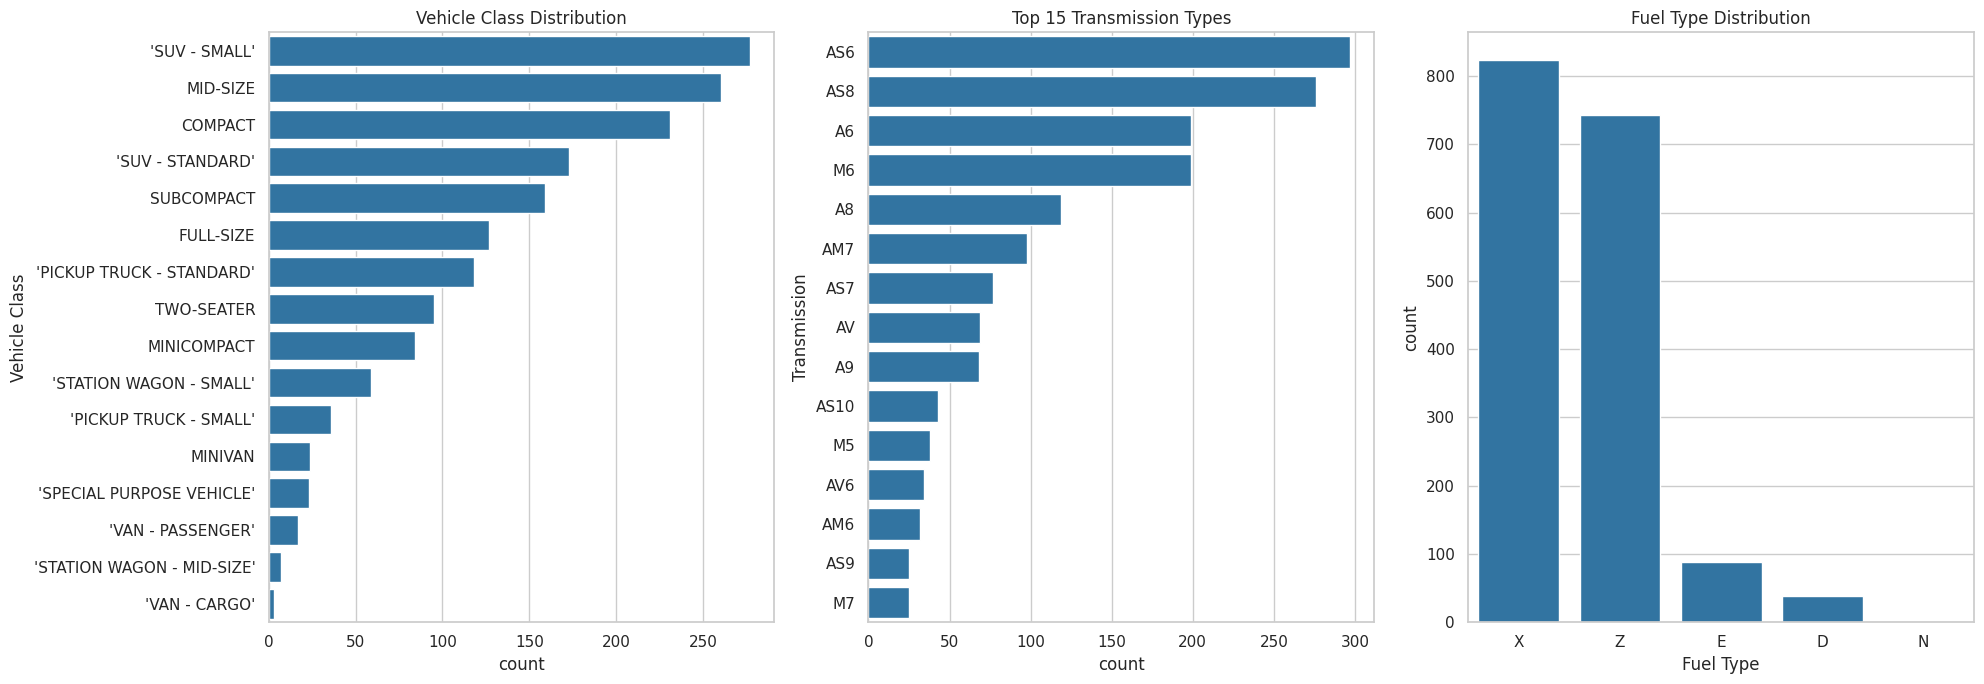

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

vehicle_order = co2_data['Vehicle Class'].value_counts().index
sns.countplot(data=co2_data, y='Vehicle Class', order=vehicle_order, ax=axes[0], color='tab:blue')
axes[0].set_title('Vehicle Class Distribution')

transmission_order = co2_data['Transmission'].value_counts().head(15).index
sns.countplot(
    data=co2_data[co2_data['Transmission'].isin(transmission_order)],
    y='Transmission',
    order=transmission_order,
    ax=axes[1],
    color='tab:blue',
)
axes[1].set_title('Top 15 Transmission Types')

fuel_order = co2_data['Fuel Type'].value_counts().index
sns.countplot(data=co2_data, x='Fuel Type', order=fuel_order, ax=axes[2], color='tab:blue')
axes[2].set_title('Fuel Type Distribution')

plt.tight_layout()
plt.show()

## 1.7 Visualization Task: Correlation Heatmap

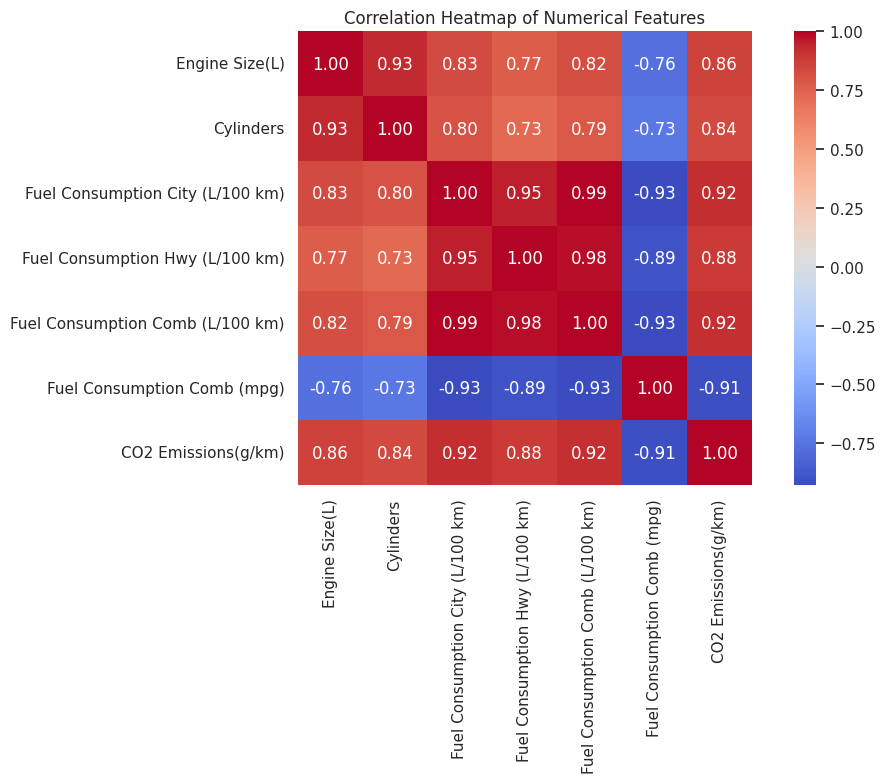

Features ordered by absolute correlation with CO2 emissions:


,Correlation with CO2 Emissions
Fuel Consumption City (L/100 km),0.9181
Fuel Consumption Comb (L/100 km),0.9154
Fuel Consumption Comb (mpg),-0.9076
Fuel Consumption Hwy (L/100 km),0.8799
Engine Size(L),0.8570
Cylinders,0.8414


In [7]:
correlation_matrix = co2_data[numerical_columns].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

co2_correlations = (
    correlation_matrix['CO2 Emissions(g/km)']
    .drop('CO2 Emissions(g/km)')
    .sort_values(key=np.abs, ascending=False)
    .rename('Correlation with CO2 Emissions')
)
print('Features ordered by absolute correlation with CO2 emissions:')
display(co2_correlations.to_frame())

## 1.8 Feature Insights: Does Fuel Type Affect Emissions?

Mean and median emissions are compared by fuel type. A one-way ANOVA is also reported as a statistical indication of whether the group means differ. This is an association test and does not establish causality.

CO2 emissions summary by fuel type:


,count,mean,median,std
Fuel Type,,,,
E,88,275.6818,275.0000,46.4873
Z,743,264.6864,253.0000,56.8107
D,38,238.7368,255.5000,47.8820
X,823,235.3475,226.0000,57.3322
N,1,213.0000,213.0000,NaN


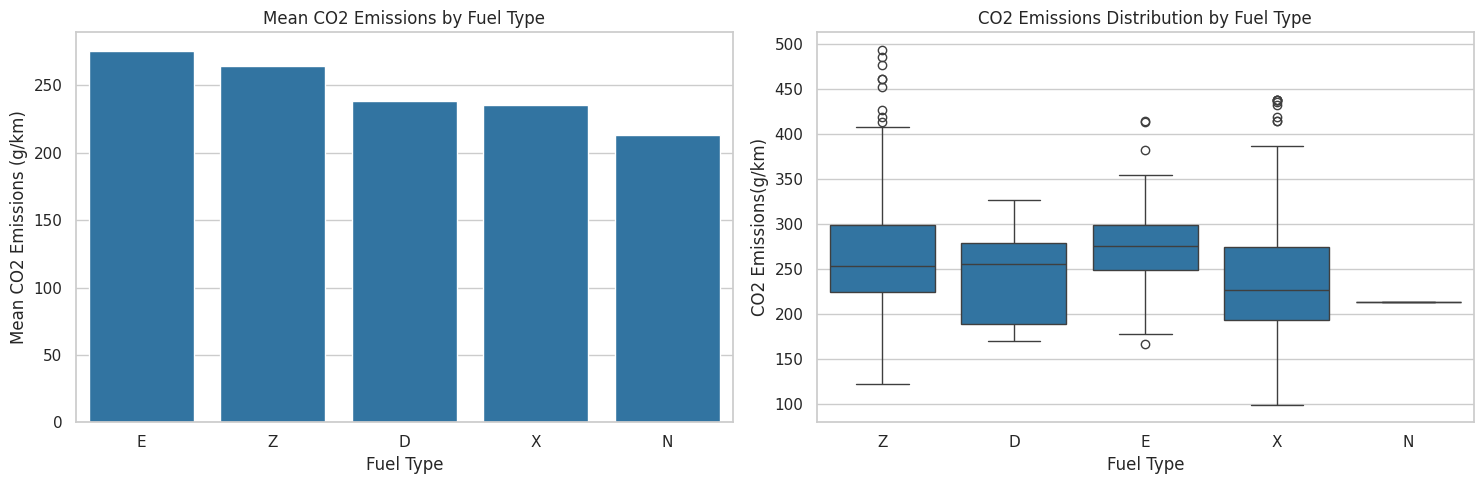

One-way ANOVA F-statistic: 41.8671
One-way ANOVA p-value: 4.29072e-26


In [8]:
fuel_summary = (
    co2_data.groupby('Fuel Type')['CO2 Emissions(g/km)']
    .agg(['count', 'mean', 'median', 'std'])
    .sort_values('mean', ascending=False)
)
print('CO2 emissions summary by fuel type:')
display(fuel_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=fuel_summary.reset_index(),
    x='Fuel Type',
    y='mean',
    ax=axes[0],
    color='tab:blue',
)
axes[0].set_title('Mean CO2 Emissions by Fuel Type')
axes[0].set_ylabel('Mean CO2 Emissions (g/km)')

sns.boxplot(
    data=co2_data,
    x='Fuel Type',
    y='CO2 Emissions(g/km)',
    ax=axes[1],
    color='tab:blue',
)
axes[1].set_title('CO2 Emissions Distribution by Fuel Type')

plt.tight_layout()
plt.show()

fuel_groups = [
    group['CO2 Emissions(g/km)'].values
    for _, group in co2_data.groupby('Fuel Type')
    if len(group) > 1
]
anova_stat, anova_p = f_oneway(*fuel_groups)
print(f"One-way ANOVA F-statistic: {anova_stat:.4f}")
print(f"One-way ANOVA p-value: {anova_p:.6g}")

## 1.9 Written Summary of Observed Trends

- Combined fuel consumption in L/100 km has the strongest positive relationship with CO2 emissions.
- Fuel consumption measured in mpg has a strong negative relationship because higher mpg represents better fuel efficiency.
- Larger engines and vehicles with more cylinders generally produce more emissions.
- Fuel type is associated with substantial differences in average emissions, as shown by the grouped statistics and ANOVA result.
- These findings describe patterns in this dataset; they should not be interpreted as proof of causation.

> **Part one is dooooooooooooooooooooooooone ✅**

---
# Part 2: Regression Analysis

## 2.1 Initial Multiple Linear Regression

The dataset is split once into 70% training and 30% testing subsets. The initial model uses exactly the three features specified in the assignment:

- Engine Size(L)
- Fuel Consumption Comb (L/100 km)
- Cylinders

In [9]:
target_column = 'CO2 Emissions(g/km)'
initial_features = [
    'Engine Size(L)',
    'Fuel Consumption Comb (L/100 km)',
    'Cylinders',
]

train_indices, test_indices = train_test_split(
    co2_data.index,
    test_size=0.30,
    random_state=RANDOM_STATE,
)

y_reg = co2_data[target_column]
X_initial = co2_data[initial_features]

X_train_initial = X_initial.loc[train_indices]
X_test_initial = X_initial.loc[test_indices]
y_train_reg = y_reg.loc[train_indices]
y_test_reg = y_reg.loc[test_indices]

initial_regression = LinearRegression()
initial_regression.fit(X_train_initial, y_train_reg)
initial_predictions = initial_regression.predict(X_test_initial)

initial_mse = mean_squared_error(y_test_reg, initial_predictions)
initial_r2 = r2_score(y_test_reg, initial_predictions)

initial_coefficients = pd.DataFrame({
    'Feature': initial_features,
    'Coefficient': initial_regression.coef_,
})

print(f"Training rows: {len(train_indices):,}")
print(f"Testing rows: {len(test_indices):,}")
print(f"Intercept: {initial_regression.intercept_:.4f}")
print(f"Test MSE: {initial_mse:.4f}")
print(f"Test R2: {initial_r2:.4f}")
print('\nInitial model coefficients:')
display(initial_coefficients)

Training rows: 1,185
Testing rows: 508
Intercept: 53.0986
Test MSE: 348.4107
Test R2: 0.9012

Initial model coefficients:


,Feature,Coefficient
0,Engine Size(L),4.8031
1,Fuel Consumption Comb (L/100 km),12.8161
2,Cylinders,7.3873


## 2.2 Initial model diagnostic plots

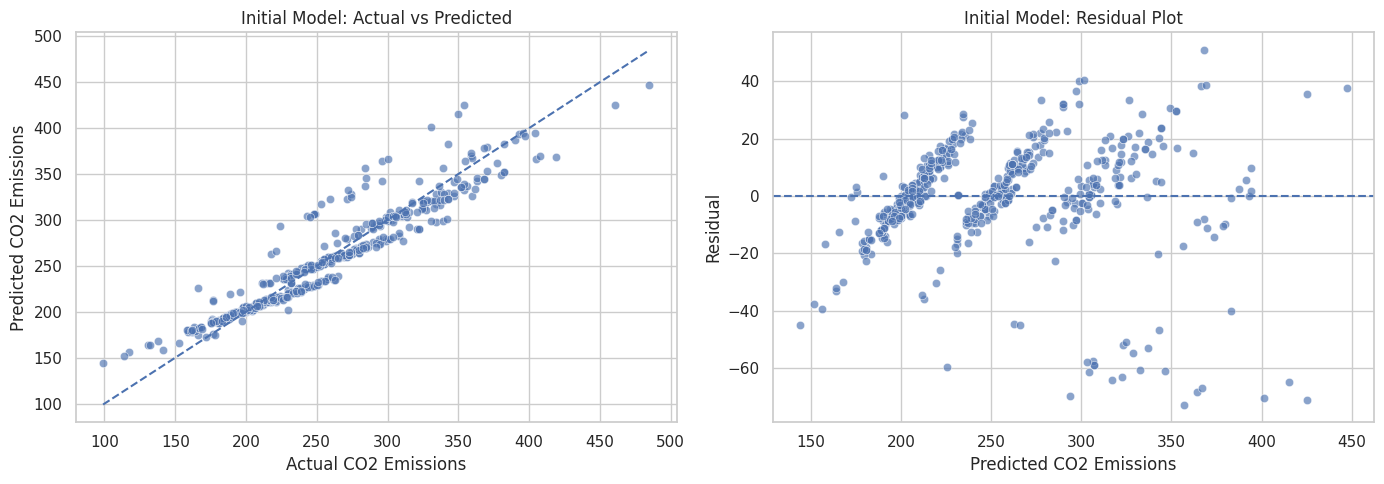

In [10]:
initial_residuals = y_test_reg - initial_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test_reg, y=initial_predictions, alpha=0.65, ax=axes[0])
line_min = min(y_test_reg.min(), initial_predictions.min())
line_max = max(y_test_reg.max(), initial_predictions.max())
axes[0].plot([line_min, line_max], [line_min, line_max], linestyle='--')
axes[0].set_title('Initial Model: Actual vs Predicted')
axes[0].set_xlabel('Actual CO2 Emissions')
axes[0].set_ylabel('Predicted CO2 Emissions')

sns.scatterplot(x=initial_predictions, y=initial_residuals, alpha=0.65, ax=axes[1])
axes[1].axhline(0, linestyle='--')
axes[1].set_title('Initial Model: Residual Plot')
axes[1].set_xlabel('Predicted CO2 Emissions')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

## 2.3 Forward Feature Selection

The initial model above intentionally uses the three predictors specified by the project instructions.

For refinement, forward selection starts from a broader set of **relevant feature groups**:

- Engine Size
- Cylinders
- City and Highway Fuel Consumption
- Vehicle Class
- Transmission
- Fuel Type

`Make` and `Model` are excluded because they contain many brand/model identifiers and would encourage memorization rather than a general relationship. Combined fuel consumption and mpg are not added to this candidate pool because they duplicate information already represented by city and highway consumption.

Categorical variables are one-hot encoded and evaluated as complete groups. At each step, the group producing the lowest 5-fold cross-validated MSE on the training data is added. Selection stops when the relative improvement is below 1%. The test set is never used during feature selection.

In [11]:
regression_base = co2_data[[
    'Engine Size(L)',
    'Cylinders',
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Vehicle Class',
    'Transmission',
    'Fuel Type',
]].copy()

categorical_regression_features = ['Vehicle Class', 'Transmission', 'Fuel Type']

regression_candidates = pd.get_dummies(
    regression_base,
    columns=categorical_regression_features,
    drop_first=True,
    dtype=int,
)

feature_groups = {
    'Engine Size(L)': ['Engine Size(L)'],
    'Cylinders': ['Cylinders'],
    'Fuel Consumption City (L/100 km)': ['Fuel Consumption City (L/100 km)'],
    'Fuel Consumption Hwy (L/100 km)': ['Fuel Consumption Hwy (L/100 km)'],
    'Vehicle Class': [
        column for column in regression_candidates.columns
        if column.startswith('Vehicle Class_')
    ],
    'Transmission': [
        column for column in regression_candidates.columns
        if column.startswith('Transmission_')
    ],
    'Fuel Type': [
        column for column in regression_candidates.columns
        if column.startswith('Fuel Type_')
    ],
}

X_train_candidates = regression_candidates.loc[train_indices]
X_test_candidates = regression_candidates.loc[test_indices]


def expand_feature_groups(selected_groups, groups):
    return [
        column
        for group_name in selected_groups
        for column in groups[group_name]
    ]


def forward_group_selection_cv(
    X_train,
    y_train,
    groups,
    min_relative_improvement=0.01,
):
    selected_groups = []
    remaining_groups = list(groups.keys())
    best_mse = np.inf
    history = []
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    while remaining_groups:
        candidate_results = []

        for candidate_group in remaining_groups:
            groups_to_test = selected_groups + [candidate_group]
            columns_to_test = expand_feature_groups(groups_to_test, groups)

            model = LinearRegression()
            cv_mse = -cross_val_score(
                model,
                X_train[columns_to_test],
                y_train,
                cv=cv,
                scoring='neg_mean_squared_error',
                n_jobs=1,
            ).mean()

            candidate_results.append((cv_mse, candidate_group))

        candidate_mse, candidate_group = min(
            candidate_results,
            key=lambda item: item[0],
        )

        if np.isfinite(best_mse):
            relative_improvement = (best_mse - candidate_mse) / best_mse
            if relative_improvement < min_relative_improvement:
                break
        else:
            relative_improvement = np.nan

        selected_groups.append(candidate_group)
        remaining_groups.remove(candidate_group)
        best_mse = candidate_mse

        history.append({
            'Step': len(selected_groups),
            'Added Feature Group': candidate_group,
            'Selected Groups': ', '.join(selected_groups),
            'Encoded Predictor Count': len(
                expand_feature_groups(selected_groups, groups)
            ),
            'CV MSE': candidate_mse,
            'Relative Improvement': relative_improvement,
        })

    selected_columns = expand_feature_groups(selected_groups, groups)
    return selected_groups, selected_columns, pd.DataFrame(history)


selected_feature_groups, selected_features, selection_history = forward_group_selection_cv(
    X_train_candidates,
    y_train_reg,
    feature_groups,
    min_relative_improvement=0.01,
)

print('Forward-selection history:')
display(selection_history)

print('Selected feature groups:')
for group_name in selected_feature_groups:
    print(f'- {group_name}')

print(f'Expanded encoded predictor count: {len(selected_features)}')

Forward-selection history:


,Step,Added Feature Group,Selected Groups,Encoded Predictor Count,CV MSE,Relative Improvement
0,1,Fuel Consumption City (L/100 km),Fuel Consumption City (L/100 km),1,561.7144,NaN
1,2,Fuel Type,"Fuel Consumption City (L/100 km), Fuel Type",5,86.1938,0.8466
2,3,Fuel Consumption Hwy (L/100 km),"Fuel Consumption City (L/100 km), Fuel Type, F...",6,44.3708,0.4852
3,4,Transmission,"Fuel Consumption City (L/100 km), Fuel Type, F...",29,42.3413,0.0457
4,5,Cylinders,"Fuel Consumption City (L/100 km), Fuel Type, F...",30,41.8244,0.0122


Selected feature groups:
- Fuel Consumption City (L/100 km)
- Fuel Type
- Fuel Consumption Hwy (L/100 km)
- Transmission
- Cylinders
Expanded encoded predictor count: 30


## 2.4 Rebuild and evaluate the refined regression model

In [12]:
refined_regression = LinearRegression()
refined_regression.fit(X_train_candidates[selected_features], y_train_reg)
refined_predictions = refined_regression.predict(
    X_test_candidates[selected_features]
)

refined_mse = mean_squared_error(y_test_reg, refined_predictions)
refined_r2 = r2_score(y_test_reg, refined_predictions)

regression_comparison = pd.DataFrame({
    'Model': [
        'Initial Multiple Linear Regression',
        'Forward-Selected Linear Regression',
    ],
    'Feature Groups': [
        ', '.join(initial_features),
        ', '.join(selected_feature_groups),
    ],
    'Encoded Predictor Count': [
        len(initial_features),
        len(selected_features),
    ],
    'Test MSE': [initial_mse, refined_mse],
    'Test R2': [initial_r2, refined_r2],
})

print('Regression model comparison:')
display(regression_comparison)

refined_coefficients = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': refined_regression.coef_,
}).sort_values('Coefficient', key=np.abs, ascending=False)

print(f"Refined model intercept: {refined_regression.intercept_:.4f}")
print('\nRefined model coefficients:')
display(refined_coefficients)

Regression model comparison:


,Model,Feature Groups,Encoded Predictor Count,Test MSE,Test R2
0,Initial Multiple Linear Regression,"Engine Size(L), Fuel Consumption Comb (L/100 k...",3,348.4107,0.9012
1,Forward-Selected Linear Regression,"Fuel Consumption City (L/100 km), Fuel Type, F...",30,25.8586,0.9927


Refined model intercept: 41.1991

Refined model coefficients:


,Feature,Coefficient
1,Fuel Type_E,-143.7078
2,Fuel Type_N,-110.0693
4,Fuel Type_Z,-31.3326
3,Fuel Type_X,-30.5460
6,Transmission_A4,-14.8297
0,Fuel Consumption City (L/100 km),12.1886
5,Fuel Consumption Hwy (L/100 km),9.9968
22,Transmission_AV10,-6.2379
23,Transmission_AV6,-5.8106
26,Transmission_M5,-5.2521


## 2.5 Refined model diagnostic plot and interpretation

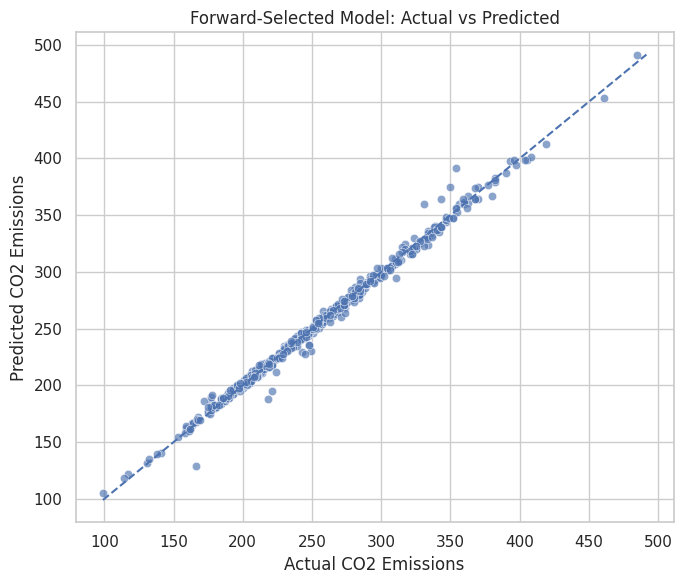

Interpretation of the initial model coefficients (holding the other features constant):
- A one-unit increase in Engine Size(L) is associated with an estimated 4.803 g/km increase in CO2 emissions.
- A one-unit increase in Fuel Consumption Comb (L/100 km) is associated with an estimated 12.816 g/km increase in CO2 emissions.
- A one-unit increase in Cylinders is associated with an estimated 7.387 g/km increase in CO2 emissions.

Important note: coefficients describe conditional associations in this dataset, not causal effects.


In [13]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test_reg, y=refined_predictions, alpha=0.65)
line_min = min(y_test_reg.min(), refined_predictions.min())
line_max = max(y_test_reg.max(), refined_predictions.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle='--')
plt.title('Forward-Selected Model: Actual vs Predicted')
plt.xlabel('Actual CO2 Emissions')
plt.ylabel('Predicted CO2 Emissions')
plt.tight_layout()
plt.show()

print('Interpretation of the initial model coefficients (holding the other features constant):')
for _, row in initial_coefficients.iterrows():
    direction = 'increase' if row['Coefficient'] >= 0 else 'decrease'
    print(
        f"- A one-unit increase in {row['Feature']} is associated with an estimated "
        f"{abs(row['Coefficient']):.3f} g/km {direction} in CO2 emissions."
    )

print('\nImportant note: coefficients describe conditional associations in this dataset, not causal effects.')

## 2.6 Optional nonlinear benchmark: Random Forest Regressor

This model is included as an additional benchmark. It is not a replacement for the required linear regression analysis.

In [14]:
random_forest_regressor = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
random_forest_regressor.fit(X_train_initial, y_train_reg)
rf_reg_predictions = random_forest_regressor.predict(X_test_initial)

rf_reg_mse = mean_squared_error(y_test_reg, rf_reg_predictions)
rf_reg_r2 = r2_score(y_test_reg, rf_reg_predictions)

print(f"Random Forest Regressor Test MSE: {rf_reg_mse:.4f}")
print(f"Random Forest Regressor Test R2: {rf_reg_r2:.4f}")

Random Forest Regressor Test MSE: 114.7205
Random Forest Regressor Test R2: 0.9675


> **Part two is dooooooooooooooooooooooooone ✅**

---
# Part 3: Classification - Loan Approval

## 3.1 Load and inspect the loan approval dataset

Column names and categorical values are cleaned. Exact duplicate rows are removed before splitting to prevent identical applicants from appearing in both training and testing data.

In [15]:
loan_raw = pd.read_csv(LOAN_FILE)
loan_raw.columns = [column.strip().strip("'").strip() for column in loan_raw.columns]

for column in loan_raw.select_dtypes(include='object').columns:
    loan_raw[column] = (
        loan_raw[column]
        .astype(str)
        .str.strip()
        .str.strip("'")
        .str.strip()
    )

print('First five rows:')
display(loan_raw.head())

loan_overview = pd.DataFrame({
    'Column': loan_raw.columns,
    'Non-Null Count': loan_raw.notna().sum().values,
    'Missing Values': loan_raw.isna().sum().values,
    'Data Type': loan_raw.dtypes.astype(str).values,
})
print('\nDataset information:')
display(loan_overview)

print(f"Raw dimensions: {loan_raw.shape[0]:,} rows x {loan_raw.shape[1]} columns")
print(f"Exact duplicate rows: {loan_raw.duplicated().sum():,}")

loan_data = loan_raw.drop_duplicates().reset_index(drop=True)
print(f"Dimensions after removing exact duplicates: {loan_data.shape[0]:,} rows x {loan_data.shape[1]} columns")
print('\nTarget distribution after duplicate removal:')
display(loan_data['loan_status'].value_counts().rename_axis('Loan Status').to_frame('Count'))

First five rows:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1103,1,Graduate,Yes,1600000,4900000,16,487,4300000,1100000,3900000,2000000,Rejected
1,2748,1,Graduate,Yes,9700000,25500000,18,741,21900000,6200000,34800000,4900000,Approved
2,3889,1,Not Graduate,No,9100000,23300000,18,792,800000,12600000,32100000,12400000,Approved
3,2921,1,Not Graduate,No,400000,1400000,4,302,200000,100000,1500000,500000,Approved
4,3589,4,Not Graduate,Yes,6900000,22000000,10,512,6100000,9100000,20600000,3900000,Rejected



Dataset information:


,Column,Non-Null Count,Missing Values,Data Type
0,loan_id,4269,0,int64
1,no_of_dependents,4269,0,int64
2,education,4269,0,object
3,self_employed,4269,0,object
4,income_annum,4269,0,int64
5,loan_amount,4269,0,int64
6,loan_term,4269,0,int64
7,cibil_score,4269,0,int64
8,residential_assets_value,4269,0,int64
9,commercial_assets_value,4269,0,int64


Raw dimensions: 4,269 rows x 13 columns
Exact duplicate rows: 2,259
Dimensions after removing exact duplicates: 2,010 rows x 13 columns

Target distribution after duplicate removal:


,Count
Loan Status,
Approved,1239
Rejected,771


## 3.2 Preprocessing strategy

- `loan_id` is an identifier and is excluded from predictors.
- Missing numerical values, if present in future data, are imputed with the median.
- Missing categorical values are imputed with the most frequent category.
- `education` and `self_employed` are one-hot encoded.
- Scaling is performed inside pipelines for Logistic Regression, Naive Bayes, and SVM.
- All preprocessing is fitted only on training folds, preventing data leakage.
- Zero values are retained because zero dependents or zero asset values can be valid observations.

In [16]:
X_classification = loan_data.drop(columns=['loan_status', 'loan_id'])
y_classification = loan_data['loan_status'].map({'Rejected': 0, 'Approved': 1})

if y_classification.isna().any():
    raise ValueError('Unexpected target labels were found in loan_status.')

categorical_features = ['education', 'self_employed']
numerical_features = [
    column for column in X_classification.columns
    if column not in categorical_features
]

numeric_scaled_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

numeric_unscaled_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', numeric_scaled_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features),
])

preprocessor_unscaled = ColumnTransformer(transformers=[
    ('num', numeric_unscaled_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features),
])

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classification,
    y_classification,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_classification,
)

print(f"Training rows: {X_train_cls.shape[0]:,}")
print(f"Testing rows: {X_test_cls.shape[0]:,}")
print(f"Training approval rate: {y_train_cls.mean():.2%}")
print(f"Testing approval rate: {y_test_cls.mean():.2%}")

Training rows: 1,407
Testing rows: 603
Training approval rate: 61.62%
Testing approval rate: 61.69%


## 3.3 Build the required classification models

In [17]:
classification_models = {
    'Decision Tree': Pipeline(steps=[
        ('preprocess', preprocessor_unscaled),
        ('model', DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]),
    'Logistic Regression': Pipeline(steps=[
        ('preprocess', preprocessor_scaled),
        ('model', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    'Naive Bayes': Pipeline(steps=[
        ('preprocess', preprocessor_scaled),
        ('model', GaussianNB()),
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocess', preprocessor_unscaled),
        ('model', RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    'SVM': Pipeline(steps=[
        ('preprocess', preprocessor_scaled),
        ('model', SVC(
            kernel='rbf',
            probability=True,
            random_state=RANDOM_STATE,
        )),
    ]),
}

fitted_models = {}
holdout_rows = []
holdout_predictions = {}
holdout_scores = {}

for model_name, model in classification_models.items():
    start_time = time.perf_counter()
    model.fit(X_train_cls, y_train_cls)
    elapsed = time.perf_counter() - start_time

    predictions = model.predict(X_test_cls)
    probabilities = model.predict_proba(X_test_cls)[:, 1]

    fitted_models[model_name] = model
    holdout_predictions[model_name] = predictions
    holdout_scores[model_name] = probabilities

    holdout_rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test_cls, predictions),
        'Precision': precision_score(y_test_cls, predictions),
        'Recall': recall_score(y_test_cls, predictions),
        'F1-Score': f1_score(y_test_cls, predictions),
        'AUC': roc_auc_score(y_test_cls, probabilities),
        'Fit Time (seconds)': elapsed,
    })

holdout_results = (
    pd.DataFrame(holdout_rows)
    .sort_values(['AUC', 'Accuracy'], ascending=False)
    .reset_index(drop=True)
)

print('Hold-out validation results (positive class = Approved):')
display(holdout_results)

Hold-out validation results (positive class = Approved):


,Model,Accuracy,Precision,Recall,F1-Score,AUC,Fit Time (seconds)
0,Random Forest,0.9751,0.9710,0.9892,0.9800,0.9960,0.3486
1,SVM,0.9154,0.9326,0.9301,0.9314,0.9714,0.0817
2,Decision Tree,0.9751,0.9710,0.9892,0.9800,0.9708,0.0097
3,Logistic Regression,0.9154,0.9235,0.9409,0.9321,0.9602,0.0160
4,Naive Bayes,0.9204,0.9286,0.9435,0.9360,0.9597,0.0083


## 3.4 Classification reports

In [18]:
for model_name in classification_models:
    print(f"\n{'=' * 72}")
    print(model_name)
    print('=' * 72)
    print(
        classification_report(
            y_test_cls,
            holdout_predictions[model_name],
            target_names=['Rejected', 'Approved'],
            digits=4,
        )
    )


Decision Tree
              precision    recall  f1-score   support

    Rejected     0.9821    0.9524    0.9670       231
    Approved     0.9710    0.9892    0.9800       372

    accuracy                         0.9751       603
   macro avg     0.9766    0.9708    0.9735       603
weighted avg     0.9753    0.9751    0.9750       603


Logistic Regression
              precision    recall  f1-score   support

    Rejected     0.9018    0.8745    0.8879       231
    Approved     0.9235    0.9409    0.9321       372

    accuracy                         0.9154       603
   macro avg     0.9126    0.9077    0.9100       603
weighted avg     0.9152    0.9154    0.9152       603


Naive Bayes
              precision    recall  f1-score   support

    Rejected     0.9067    0.8831    0.8947       231
    Approved     0.9286    0.9435    0.9360       372

    accuracy                         0.9204       603
   macro avg     0.9176    0.9133    0.9154       603
weighted avg     0.9202  

## 3.5 Confusion Matrices

Each classifier is displayed in its **own figure** so the four outcomes are easy to read:

- **TN**: correctly predicted Rejected
- **FP**: incorrectly predicted Approved
- **FN**: incorrectly predicted Rejected
- **TP**: correctly predicted Approved

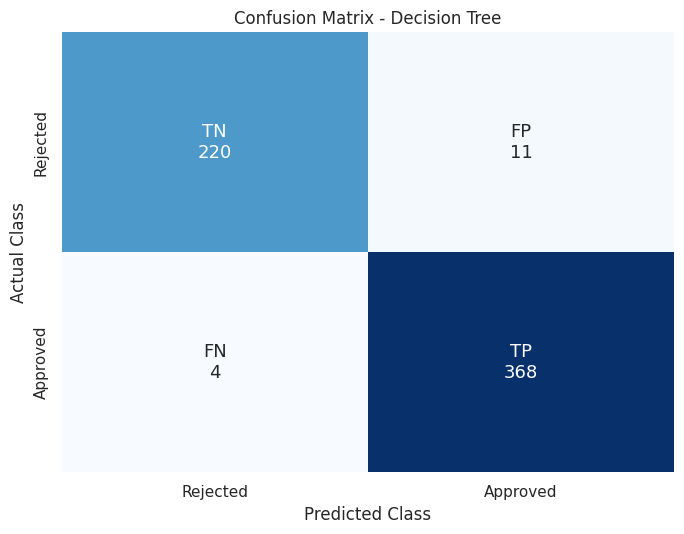

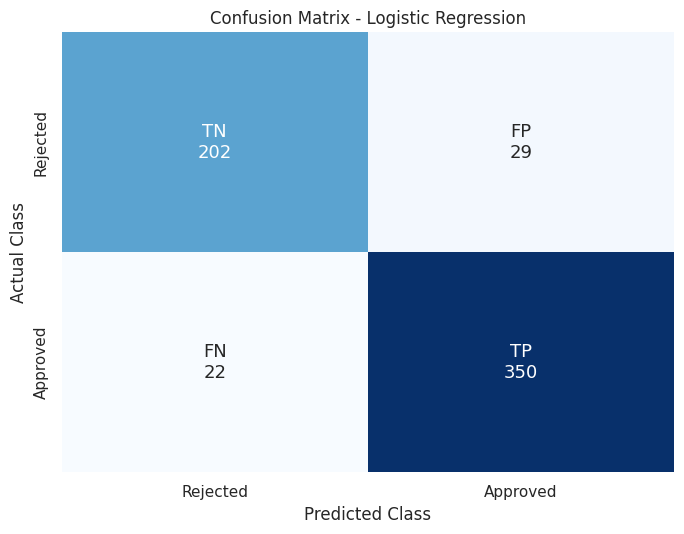

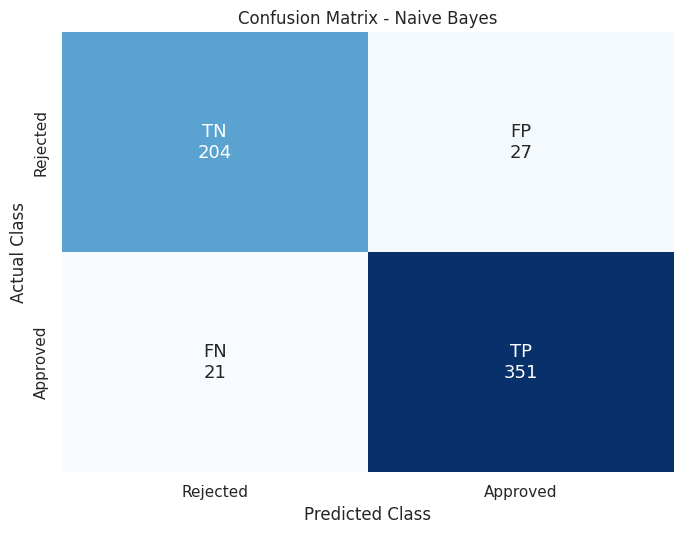

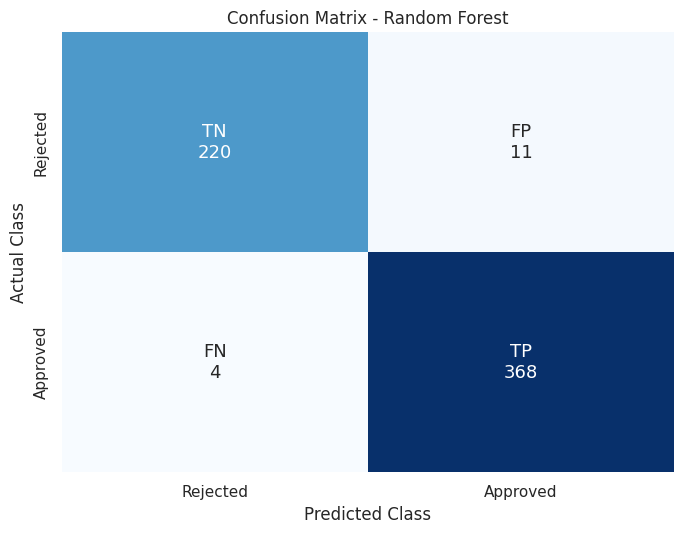

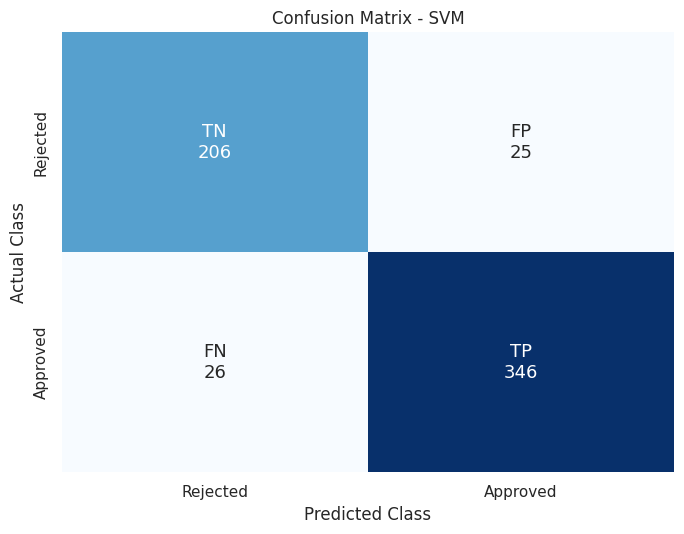

In [19]:
for model_name in classification_models:
    matrix = confusion_matrix(
        y_test_cls,
        holdout_predictions[model_name],
        labels=[0, 1],
    )

    tn, fp, fn, tp = matrix.ravel()
    annotations = np.array([
        [f'TN\n{tn}', f'FP\n{fp}'],
        [f'FN\n{fn}', f'TP\n{tp}'],
    ])

    plt.figure(figsize=(7, 5.5))
    sns.heatmap(
        matrix,
        annot=annotations,
        fmt='',
        cmap='Blues',
        cbar=False,
        xticklabels=['Rejected', 'Approved'],
        yticklabels=['Rejected', 'Approved'],
        annot_kws={'size': 13},
    )
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.tight_layout()
    plt.show()

## 3.6 ROC curves and AUC

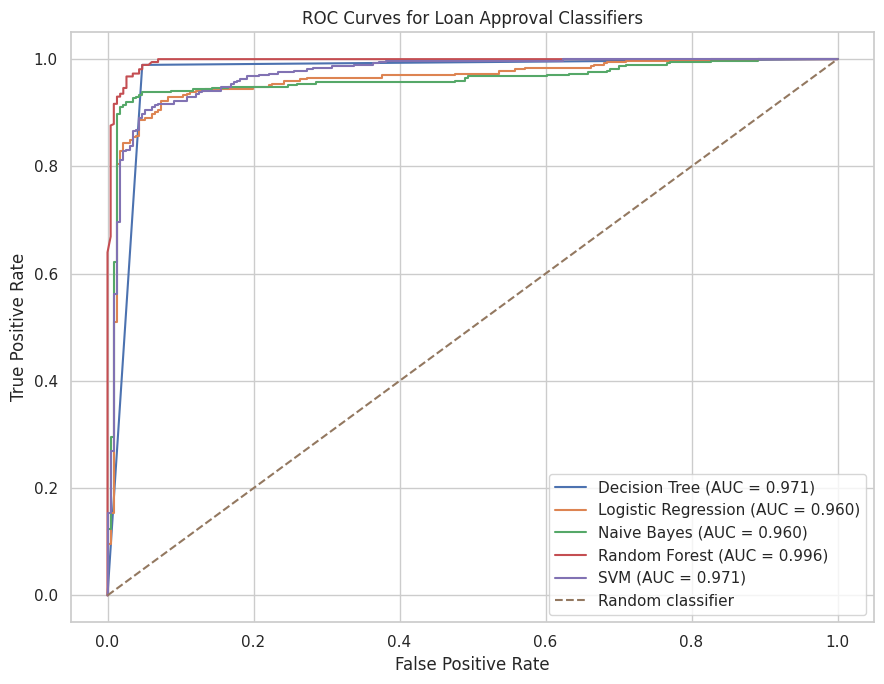

In [20]:
plt.figure(figsize=(9, 7))

for model_name in classification_models:
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test_cls,
        holdout_scores[model_name],
    )
    model_auc = roc_auc_score(y_test_cls, holdout_scores[model_name])
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f'{model_name} (AUC = {model_auc:.3f})',
    )

plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Loan Approval Classifiers')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 3.7 Compare hold-out validation with 10-fold cross-validation

A stratified 10-fold procedure is used so every fold maintains approximately the same class distribution. Each complete pipeline is cross-validated, which prevents preprocessing leakage.

In [21]:
stratified_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

cv_rows = []

for model_name, model in classification_models.items():
    cv_output = cross_validate(
        model,
        X_classification,
        y_classification,
        cv=stratified_cv,
        scoring=scoring_metrics,
        n_jobs=1,
        return_train_score=False,
    )

    cv_rows.append({
        'Model': model_name,
        'CV Accuracy Mean': cv_output['test_accuracy'].mean(),
        'CV Accuracy Std': cv_output['test_accuracy'].std(),
        'CV Precision Mean': cv_output['test_precision'].mean(),
        'CV Recall Mean': cv_output['test_recall'].mean(),
        'CV F1 Mean': cv_output['test_f1'].mean(),
        'CV AUC Mean': cv_output['test_roc_auc'].mean(),
    })

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values(['CV AUC Mean', 'CV Accuracy Mean'], ascending=False)
    .reset_index(drop=True)
)

validation_comparison = holdout_results.merge(cv_results, on='Model')
print('Hold-out and 10-fold cross-validation comparison:')
display(validation_comparison)

Hold-out and 10-fold cross-validation comparison:


,Model,Accuracy,Precision,Recall,F1-Score,AUC,Fit Time (seconds),CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV AUC Mean
0,Random Forest,0.9751,0.9710,0.9892,0.9800,0.9960,0.3486,0.9766,0.0063,0.9808,0.9814,0.9810,0.9978
1,SVM,0.9154,0.9326,0.9301,0.9314,0.9714,0.0817,0.9333,0.0148,0.9504,0.9411,0.9457,0.9810
2,Decision Tree,0.9751,0.9710,0.9892,0.9800,0.9708,0.0097,0.9766,0.0089,0.9839,0.9782,0.9809,0.9761
3,Logistic Regression,0.9154,0.9235,0.9409,0.9321,0.9602,0.0160,0.9154,0.0185,0.9324,0.9306,0.9314,0.9694
4,Naive Bayes,0.9204,0.9286,0.9435,0.9360,0.9597,0.0083,0.9318,0.0194,0.9496,0.9395,0.9444,0.9687


## 3.8 Selected classifier and reasons for selection

In [22]:
best_model_row = cv_results.iloc[0]
best_model_name = best_model_row['Model']
best_holdout_row = holdout_results.loc[
    holdout_results['Model'] == best_model_name
].iloc[0]

print(f"Selected classifier: {best_model_name}")
print(f"Hold-out Accuracy: {best_holdout_row['Accuracy']:.4f}")
print(f"Hold-out AUC: {best_holdout_row['AUC']:.4f}")
print(f"10-fold CV Accuracy: {best_model_row['CV Accuracy Mean']:.4f} +/- {best_model_row['CV Accuracy Std']:.4f}")
print(f"10-fold CV AUC: {best_model_row['CV AUC Mean']:.4f}")

print('\nReasons for selection:')
print('- It achieved the strongest overall cross-validated discrimination and accuracy.')
print('- Its hold-out and cross-validation results are consistent, suggesting stable generalization.')
print('- As an ensemble, Random Forest is generally less sensitive than a single Decision Tree to the specific training sample.')
print('- It can model nonlinear relationships and interactions without requiring manual feature transformations.')

Selected classifier: Random Forest
Hold-out Accuracy: 0.9751
Hold-out AUC: 0.9960
10-fold CV Accuracy: 0.9766 +/- 0.0063
10-fold CV AUC: 0.9978

Reasons for selection:
- It achieved the strongest overall cross-validated discrimination and accuracy.
- Its hold-out and cross-validation results are consistent, suggesting stable generalization.
- As an ensemble, Random Forest is generally less sensitive than a single Decision Tree to the specific training sample.
- It can model nonlinear relationships and interactions without requiring manual feature transformations.


## 3.9 Random Forest feature importance

Random Forest feature importance:


,Feature,Importance
0,cibil_score,0.7729
1,loan_term,0.0623
2,loan_amount,0.0303
3,commercial_assets_value,0.0239
4,bank_asset_value,0.0235
5,luxury_assets_value,0.0228
6,residential_assets_value,0.0224
7,income_annum,0.0212
8,no_of_dependents,0.0105
9,self_employed_Yes,0.0031


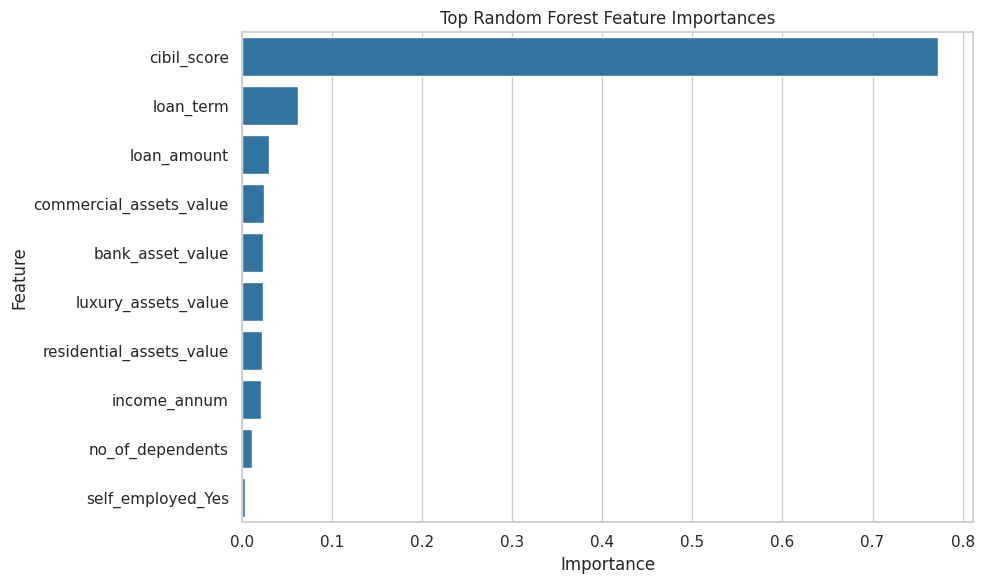

In [23]:
selected_pipeline = fitted_models['Random Forest']
preprocessor = selected_pipeline.named_steps['preprocess']
random_forest_model = selected_pipeline.named_steps['model']

feature_names = preprocessor.get_feature_names_out()
clean_feature_names = [name.split('__', 1)[-1] for name in feature_names]

importance_table = (
    pd.DataFrame({
        'Feature': clean_feature_names,
        'Importance': random_forest_model.feature_importances_,
    })
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print('Random Forest feature importance:')
display(importance_table)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_table.head(10), x='Importance', y='Feature', color='tab:blue')
plt.title('Top Random Forest Feature Importances')
plt.tight_layout()
plt.show()

# Final Project Summary

- The CO2 section includes data-quality checks, explicit preprocessing decisions, six scatterplots, a pair plot, categorical plots, a correlation heatmap, and written feature insights.
- The initial regression model uses the exact three required predictors and a 70/30 train/test split.
- Forward selection evaluates broader relevant feature groups on training data only, using 5-fold cross-validated MSE.
- High-cardinality identifiers (`Make` and `Model`) and redundant fuel-consumption representations are excluded from the refined candidate set for documented reasons.
- The classification section uses leak-safe preprocessing pipelines.
- Decision Tree, Logistic Regression, Naive Bayes, Random Forest, and SVM are evaluated using Accuracy, Precision, Recall, F1-Score, AUC, individual confusion matrices, hold-out validation, and stratified 10-fold cross-validation.
- Random Forest is selected using both hold-out and cross-validation evidence.